## PART ONE: Data Acquisition and Exploration

In [33]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading my dataset from the desktop.
# Dataset was downloaded from: https://crudata.uea.ac.uk/cru/data/hrg/
ds = xr.open_dataset("C:/Users/USER/Desktop/Ethiopia/cru_ts4.07.1901.2022.pre.dat.nc")

# Defining the bounding box for Ethiopia
lat_min, lat_max = 3, 15
lon_min, lon_max = 33, 48

# Slicing data for the required period (1990-2020) and region of concentration 
ethiopia_data = ds.sel(lat=slice(lat_min, lat_max), 
                       lon=slice(lon_min, lon_max), 
                       time=slice('1990-01-01', '2020-12-31'))
print(ds) #show results 

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 1464, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2022-12-16
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    pre      (time, lat, lon) float32 2GB ...
    stn      (time, lat, lon) float64 3GB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk


In [34]:
# Calculating the mean precipitation over time(1990-2020)
mean_pre = ethiopia_data['pre'].mean(dim='time')
mean_pre 

<xarray.DataArray 'pre' (lat: 24, lon: 30)> Size: 3kB
array([[ 93.98248  ,  76.828    ,  63.130653 ,  46.97149  ,  30.443005 ,
         21.00807  ,  25.575796 ,  33.04948  ,  34.705364 ,  44.725014 ,
         44.033306 ,  44.080917 ,  47.4406   ,  45.947308 ,  39.029583 ,
         36.298416 ,  32.619358 ,  33.02553  ,  29.511286 ,  32.48549  ,
         40.176586 ,  43.973705 ,  41.646774 ,  38.180687 ,  35.768803 ,
         35.32665  ,  34.883396 ,  33.151897 ,         nan,         nan],
       [ 81.12686  ,  73.964806 ,  63.929565 ,  37.830647 ,  28.528494 ,
         22.984955 ,  25.684938 ,  34.481735 ,  36.363163 ,  44.47984  ,
         49.341644 ,  55.150295 ,  55.747334 ,  49.31989  ,  43.22152  ,
         37.625813 ,  30.7137   ,  25.861273 ,  23.88926  ,  26.986288 ,
         34.382256 ,  39.792778 ,  38.795177 ,  34.67449  ,  31.5301   ,
         30.21342  ,  29.416712 ,  28.438175 ,  27.92498  ,         nan],
       [ 73.11536  ,  74.49567  ,  54.39086  ,  39.450554 ,  33.20322  ,
         31.544083 ,  30.208866 ,  38.94301  ,  45.64971  ,  50.721222 ,
         62.042496 ,  58.74971  ,  55.777214 ,  52.58872  ,  49.57125  ,
         39.135735 ,  33.984127 ,  25.142467 ,  23.175264 ,  26.397041 ,
         30.389246 ,  34.52849  ,  33.57929  ,  30.074192 ,  26.2231   ,
         26.185457 ,  23.315313 ,  22.202143 ,  23.225822 ,  24.218819 ],
       [ 67.43491  ,  64.85943  ,  55.48117  ,  46.46293  ,  49.038174 ,
         42.770683 ,  41.011833 ,  46.280884 ,  59.211304 ,  57.17609  ,
...
          9.205655 ,   4.69381  ,   3.4663992,         nan,         nan],
       [ 28.31317  ,  36.493824 ,  42.744617 ,  47.59812  ,  52.562626 ,
         54.473377 ,  52.818817 ,  52.58951  ,  58.68843  ,  49.36503  ,
         49.81212  ,  46.88041  ,  47.439774 ,  45.082787 ,  18.097307 ,
         12.679304 ,  16.01425  ,  12.804036 ,   6.841669 ,   7.2862883,
          7.935761 ,  29.006708 ,  44.73443  ,  38.04782  ,  33.319077 ,
         25.373932 ,  15.547056 ,   7.326341 ,   5.7771473,   3.1577957],
       [ 26.598927 ,  31.51398  ,  36.33118  ,  40.990864 ,  44.42822  ,
         45.015038 ,  43.957767 ,  43.291126 ,  43.89865  ,  41.78629  ,
         45.441936 ,  43.482254 ,  45.015057 ,  40.067463 ,  16.196507 ,
         14.984137 ,  14.6505375,   8.595432 ,         nan,   9.254031 ,
          8.677146 ,  29.66263  ,  48.27497  ,  47.845127 ,  40.14514  ,
         36.193268 ,  29.800001 ,  22.14679  ,  16.294369 ,   8.774473 ],
       [ 21.737907 ,  25.913702 ,  29.251081 ,  32.22311  ,  33.638454 ,
         33.305637 ,  33.73091  ,  35.381454 ,  36.974716 ,  35.663464 ,
         37.521236 ,  39.795967 ,  39.56587  ,  30.572851 ,  14.505919 ,
         12.521247 ,  10.355093 ,         nan,         nan,   7.1395154,
          9.39219  ,  32.08228  ,  45.56345  ,  42.258896 ,  35.532494 ,
         27.62015  ,  22.033875 ,  19.2758   ,  21.706446 ,  18.08737  ]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 96B 3.25 3.75 4.25 4.75 ... 13.25 13.75 14.25 14.75
  * lon      (lon) float32 120B 33.25 33.75 34.25 34.75 ... 46.75 47.25 47.75

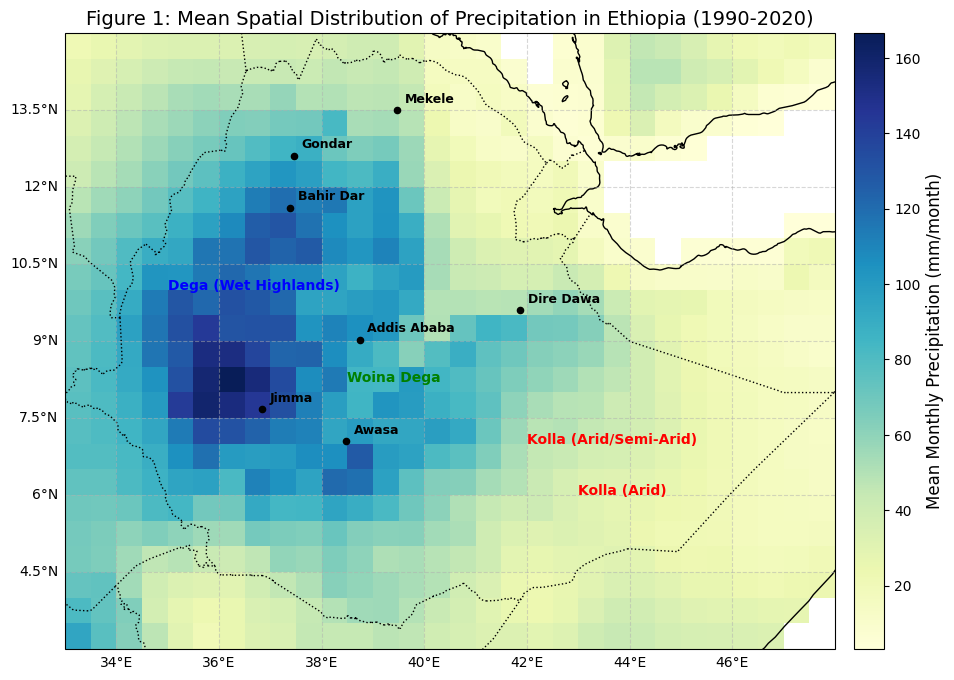

In [36]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Create the Map
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic details
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# 5. Defined and Plot Major Towns
cities = {
    'Addis Ababa': [38.74, 9.03],
    'Mekele': [39.47, 13.50],
    'Bahir Dar': [37.38, 11.60],
    'Dire Dawa': [41.87, 9.60],
    'Gondar': [37.46, 12.61],
    'Awasa': [38.47, 7.05],
    'Jimma': [36.83, 7.67]
}

for city, coord in cities.items():
    lon, lat = coord
    # Plot the city point
    ax.scatter(lon, lat, color='black', marker='o', s=20, transform=ccrs.PlateCarree(), zorder=5)
    # Add the city name (shifted slightly for clarity)
    ax.text(lon + 0.15, lat + 0.15, city, fontsize=9, transform=ccrs.PlateCarree(), 
            fontweight='bold', color='black', zorder=5)

# 6. Identifying Climate Zones (Keeping your previous labels)
plt.text(43, 6, 'Kolla (Arid)', color='red', weight='bold', transform=ccrs.PlateCarree())
plt.text(35, 10, 'Dega (Wet Highlands)', color='blue', weight='bold', transform=ccrs.PlateCarree())
plt.text(38.5, 8.2, 'Woina Dega', color='green', weight='bold', transform=ccrs.PlateCarree())

plt.title('Figure 1: Mean Precipitation in Ethiopia with Major Towns (1990-2020)', fontsize=14)




# Plot the data
mesh = mean_pre.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu', 
    add_colorbar=False
)

# Add colorbar
cbar = plt.colorbar(mesh, orientation='vertical', pad=0.02, aspect=20)
cbar.set_label('Mean Monthly Precipitation (mm/month)', fontsize=12)

# 5. Identifying Climate Zones (Adding Labels/Annotations)
# Based on typical Ethiopia Rainfall thresholds:
# Kolla (Arid) < 50mm | Woina Dega (Moderate) 50-100mm | Dega (Wet) > 100mm
plt.text(42, 7, 'Kolla (Arid/Semi-Arid)', color='red', weight='bold', transform=ccrs.PlateCarree())


plt.title('Figure 1: Mean Spatial Distribution of Precipitation in Ethiopia (1990-2020)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Gridlines for coordinates
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.savefig('Ethiopia_Mean_Precipitation_Map.png', dpi=300, bbox_inches='tight')
plt.show()

## Part 2: Temporal Analysis

In [37]:
# aggregated data by year  
annual_pre = ethiopia_data['pre'].resample(time='1YE').mean().mean(dim=['lat', 'lon'])
annual_pre 


<xarray.DataArray 'pre' (time: 31)> Size: 124B
array([46.906036, 48.80699 , 48.903976, 54.372776, 53.248756, 48.02869 ,
       54.10297 , 56.32188 , 55.347416, 50.688183, 54.726574, 51.26519 ,
       48.566853, 51.7532  , 51.96371 , 53.931774, 55.624912, 56.41663 ,
       54.50441 , 48.737766, 55.059437, 52.585815, 55.118195, 58.139023,
       58.338093, 53.580418, 57.432796, 61.167694, 58.563198, 65.485634,
       59.43403 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 248B 1990-12-31 1991-12-31 ... 2020-12-31

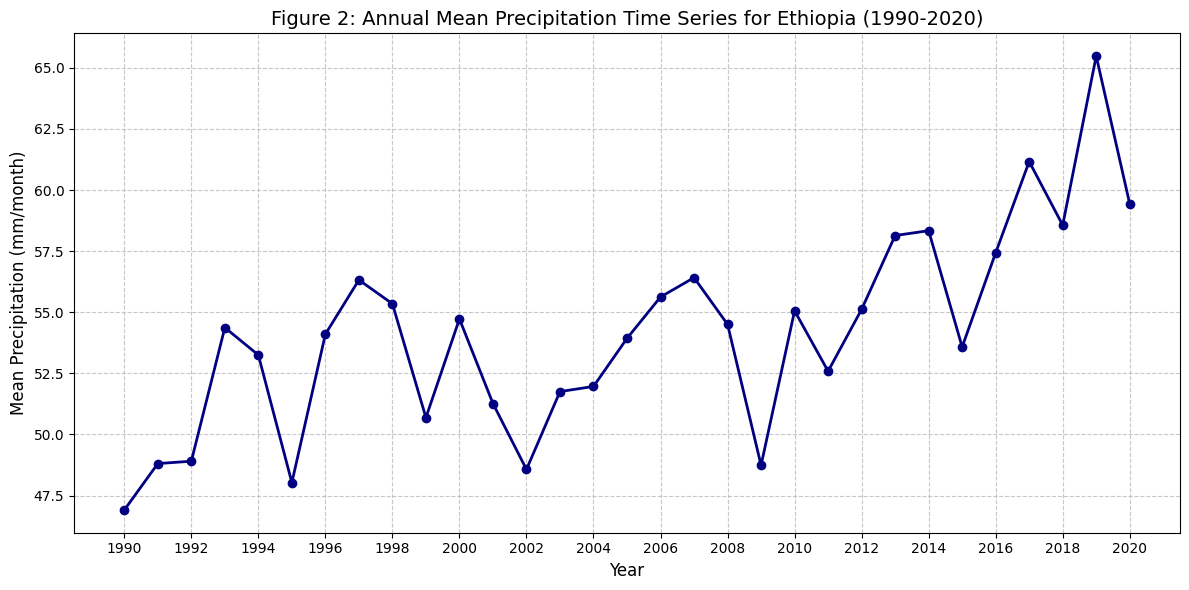

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Temporal Aggregation (Monthly to Annual) ---
# We use .resample(time='1YE').mean() to compute the mean precipitation 
# for each year at every grid point within the Ethiopia bounding box.
annual_data_per_grid = ethiopia_data['pre'].resample(time='1YE').mean()

# --- STEP 2: Spatial Aggregation (Average across the Bounding Box) ---
# Now we average all the grid points (lat and lon) to get a single 
# value representing the country-wide average for each year.
annual_mean_series = annual_data_per_grid.mean(dim=['lat', 'lon'])

# --- STEP 3: Plotting the Time Series ---
plt.figure(figsize=(12, 6))
years = annual_mean_series.time.dt.year # Extracts years for the x-axis

plt.plot(years, annual_mean_series.values, marker='o', color='navy', linestyle='-', linewidth=2)

# Formatting the plot as per grading rubric requirements (Part 2)
plt.title('Figure 2: Annual Mean Precipitation Time Series for Ethiopia (1990-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Precipitation (mm/month)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1990, 2021, 2)) # Ensure x-axis labels are readable
plt.savefig('Annual Mean Precipitation Time Series.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [10]:
# 2.1 Calculate Annual Mean
annual_pre = ethiopia_data['pre'].resample(time='1YE').mean().mean(dim=['lat', 'lon'])
annual_pre 

<xarray.DataArray 'pre' (time: 31)> Size: 124B
array([46.906036, 48.80699 , 48.903976, 54.372776, 53.248756, 48.02869 ,
       54.10297 , 56.32188 , 55.347416, 50.688183, 54.726574, 51.26519 ,
       48.566853, 51.7532  , 51.96371 , 53.931774, 55.624912, 56.41663 ,
       54.50441 , 48.737766, 55.059437, 52.585815, 55.118195, 58.139023,
       58.338093, 53.580418, 57.432796, 61.167694, 58.563198, 65.485634,
       59.43403 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 248B 1990-12-31 1991-12-31 ... 2020-12-31

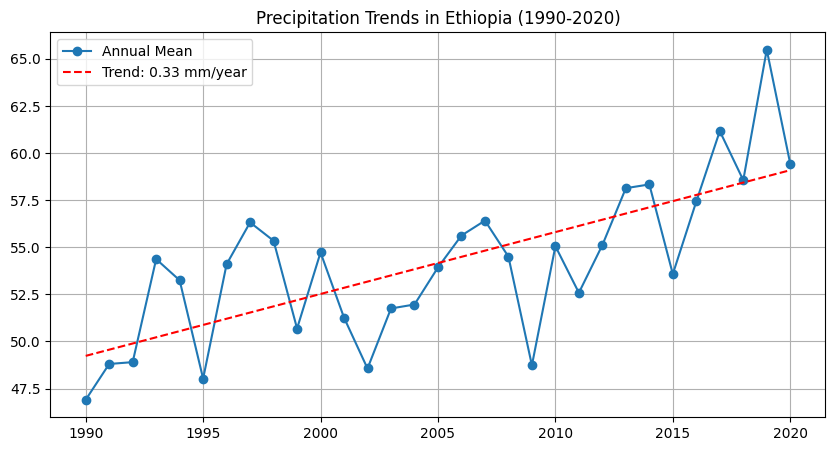

In [11]:
# 2.2 Calculate Linear Trend using Polyfit
years = np.arange(1990, 2021)
slope, intercept = np.polyfit(years, annual_pre.values, 1)
trend_line = slope * years + intercept

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(years, annual_pre, marker='o', label='Annual Mean')
plt.plot(years, trend_line, color='red', linestyle='--', label=f'Trend: {slope:.2f} mm/year')
plt.title('Precipitation Trends in Ethiopia (1990-2020)')
plt.legend()
plt.grid(True)
plt.savefig('Annual Mean Precipitation Trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# --- STEP 1: Calculate the Standard Deviation ---
# We use the 'annual_mean_series' calculated in Part 2.1
std_dev = annual_mean_series.std().values
std_dev

array(4.11935472)

Standard Deviation of Annual Mean Precipitation: 4.12 mm/month
Coefficient of Variation (CV): 7.61%


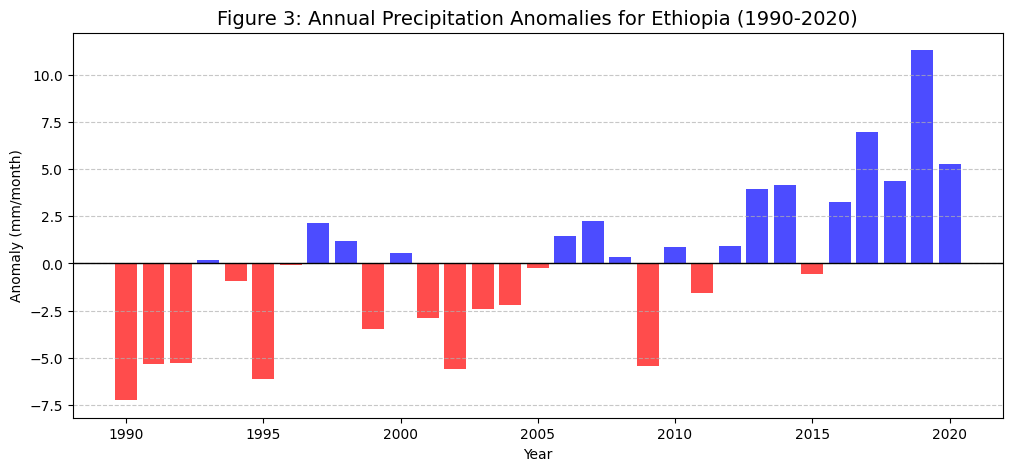

In [13]:
# --- STEP 2: Calculate the Coefficient of Variation (CV) ---
# This is optional but highly recommended for the "Interpretation" marks.
# CV = (Standard Deviation / Mean) * 100
mean_val = annual_mean_series.mean().values
cv = (std_dev / mean_val) * 100

print(f"Standard Deviation of Annual Mean Precipitation: {std_dev:.2f} mm/month")
print(f"Coefficient of Variation (CV): {cv:.2f}%")

# --- STEP 3: Visualizing Variability (Anomaly Plot) ---
# It is easier to discuss variability by looking at anomalies (Yearly Value - Long Term Mean)
anomalies = annual_mean_series - mean_val

plt.figure(figsize=(12, 5))
colors = ['blue' if x > 0 else 'red' for x in anomalies]
plt.bar(years, anomalies, color=colors, alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.title('Figure 3: Annual Precipitation Anomalies for Ethiopia (1990-2020)', fontsize=14)
plt.ylabel('Anomaly (mm/month)')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Part 3: Spatial Patterns over Time

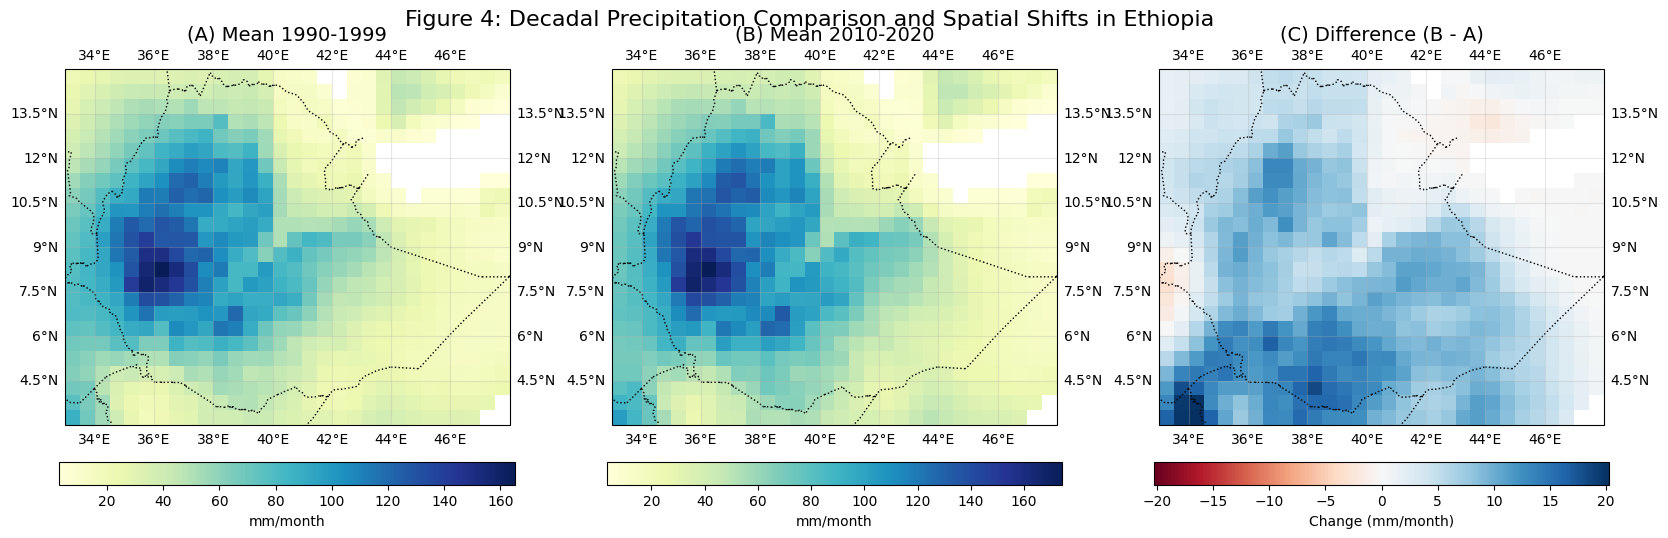

<xarray.DataArray 'pre' (lat: 24, lon: 30)> Size: 3kB
array([[ 87.681656 ,  68.81834  ,  54.72168  ,  40.159996 ,  26.127493 ,
         18.025831 ,  21.563332 ,  27.63583  ,  29.397509 ,  38.223335 ,
         38.19665  ,  38.9525   ,  42.565845 ,  41.456657 ,  35.926674 ,
         33.500008 ,  29.975832 ,  30.411673 ,  26.9175   ,  29.063332 ,
         35.133335 ,  38.16833  ,  35.991673 ,  33.1375   ,  31.365    ,
         31.385836 ,  31.628334 ,  31.073341 ,         nan,         nan],
       [ 75.97251  ,  65.74082  ,  55.524162 ,  32.493332 ,  24.466667 ,
         19.58333  ,  21.433329 ,  28.8825   ,  31.263323 ,  38.216663 ,
         42.69334  ,  48.741657 ,  49.74751  ,  44.452496 ,  39.37     ,
         34.245834 ,  27.78166  ,  23.255835 ,  21.215    ,  23.965    ,
         29.838337 ,  33.980007 ,  32.765835 ,  29.32417  ,  26.861664 ,
         26.065    ,  25.986664 ,  26.033337 ,  26.612501 ,         nan],
       [ 68.16501  ,  66.95     ,  47.30166  ,  33.835003 ,  28.3358

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Slice the data into two decades
decade_1 = ethiopia_data['pre'].sel(time=slice('1990-01-01', '1999-12-31'))
decade_3 = ethiopia_data['pre'].sel(time=slice('2010-01-01', '2020-12-31'))

# 2. Calculate the mean for each decade
mean_dec1 = decade_1.mean(dim='time')
mean_dec3 = decade_3.mean(dim='time')

# 3. Calculate the difference (Recent Decade minus First Decade)
diff_map = mean_dec3 - mean_dec1

# 4. Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# List of data and titles for easy plotting
data_to_plot = [mean_dec1, mean_dec3, diff_map]
titles = ['(A) Mean 1990-1999', '(B) Mean 2010-2020', '(C) Difference (B - A)']
cmaps = ['YlGnBu', 'YlGnBu', 'RdBu'] # Use Diverging map for difference

for i, ax in enumerate(axes):
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([33, 48, 3, 15]) # Ethiopia Bounding Box
    
    # Plotting
    im = data_to_plot[i].plot(ax=ax, transform=ccrs.PlateCarree(), 
                              cmap=cmaps[i], add_colorbar=False)
    
    # Add Colorbar
    label = 'mm/month' if i < 2 else 'Change (mm/month)'
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, label=label)
    
    ax.set_title(titles[i], fontsize=14)
    ax.gridlines(draw_labels=True, alpha=0.3)

plt.suptitle('Figure 4: Decadal Precipitation Comparison and Spatial Shifts in Ethiopia', fontsize=16)
plt.savefig('Decadal Precipitation Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(mean_dec1)
print(mean_dec3)

In [20]:
import pandas as pd

# 1. Convert the Difference Map from Monthly to Annual change
# (Difference in mean monthly * 12 months = Change in mm per year)
annual_diff = diff_map * 12

# 2. Convert the xarray DataArray to a Pandas DataFrame
df_diff = annual_diff.to_dataframe(name='Change_mm_per_year').reset_index()

# 3. Drop any rows with missing data (NaNs) which usually fall outside the map
df_diff = df_diff.dropna()

# 4. Identify Top 5 Increases (Largest positive values)
top_5_increase = df_diff.nlargest(5, 'Change_mm_per_year')

# 5. Identify Top 5 Decreases (Largest negative values / Smallest numbers)
top_5_decrease = df_diff.nsmallest(5, 'Change_mm_per_year')

# --- Displaying the Tables ---
print("TABLE 1: Top 5 Grid Points with Largest Increase (Hotspots)")
print(top_5_increase[['lat', 'lon', 'Change_mm_per_year']].to_string(index=False))

print("\n" + "="*50 + "\n")

print("TABLE 2: Top 5 Grid Points with Largest Decrease (Coldspots)")
print(top_5_decrease[['lat', 'lon', 'Change_mm_per_year']].to_string(index=False))



TABLE 1: Top 5 Grid Points with Largest Increase (Hotspots)
 lat   lon  Change_mm_per_year
3.25 34.25          243.594452
3.75 34.25          240.837341
3.25 33.75          236.725433
3.75 33.75          234.200958
4.25 38.25          220.065033


TABLE 2: Top 5 Grid Points with Largest Decrease (Coldspots)
  lat   lon  Change_mm_per_year
 7.75 33.25          -38.956512
 8.25 33.25          -36.492645
 7.25 33.25          -29.790070
13.25 44.25          -28.349991
13.25 43.75          -23.089966


## Part 4: Extreme Event Analysis

C:\Users\USER\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


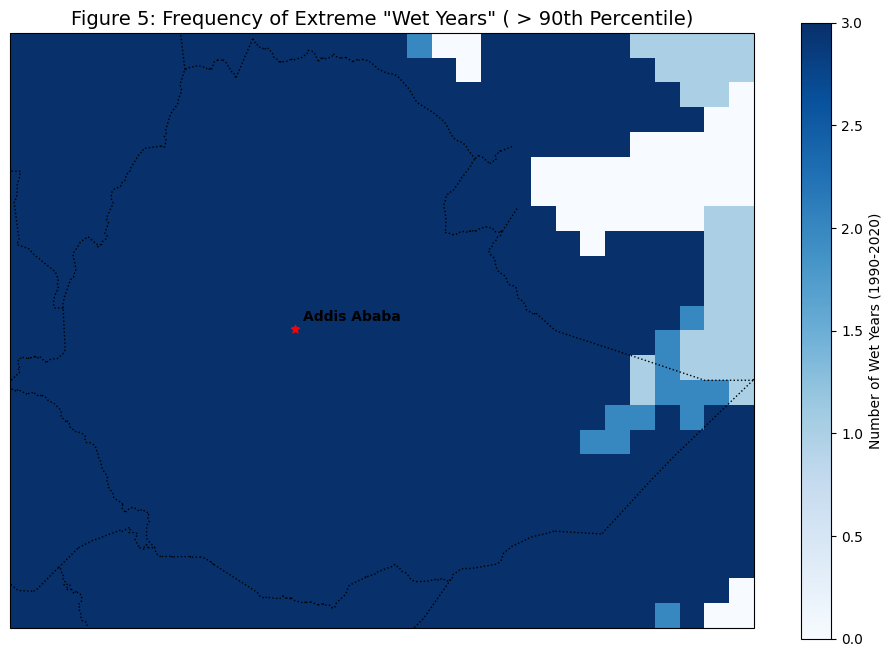

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Aggregate Monthly Data to Annual Totals/Means per Grid Cell
# Note: The assignment mentions 'annual mean', so we calculate the mean for each year.
annual_grid = ethiopia_data['pre'].resample(time='1YE').mean()

# 2. Calculate the 90th Percentile Threshold for each individual grid cell
# This creates a 2D map of thresholds (one value for every lat/lon point)
threshold_90 = annual_grid.quantile(0.9, dim='time')

# 3. Identify 'Wet Years'
# Compare each year's value to the threshold. This creates a Boolean (True/False) array.
is_wet_year = annual_grid > threshold_90

# 4. Count the number of Wet Years per grid cell
# True counts as 1, False counts as 0
wet_year_frequency = is_wet_year.sum(dim='time')

# 5. Plotting the Spatial Map
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic details and town markers
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([33, 48, 3, 15]) # Ethiopia Bounding Box

# Plot the frequency
# Frequency will likely range from 2 to 5 years given the 30-year span
mesh = wet_year_frequency.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='Blues', 
    cbar_kwargs={'label': 'Number of Wet Years (1990-2020)'}
)

# Re-add Addis Ababa for context
ax.scatter(38.74, 9.03, color='red', marker='*', transform=ccrs.PlateCarree())
ax.text(38.9, 9.2, 'Addis Ababa', color='black', fontweight='bold', transform=ccrs.PlateCarree())

plt.title('Figure 5: Frequency of Extreme "Wet Years" ( > 90th Percentile)', fontsize=14)
plt.savefig('Frequency of Extreme Wet Years.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
import xarray as xr
import numpy as np

# Example 1: Daily data -> mean daily precipitation (1990-2020)
ds = xr.open_dataset("C:/Users/USER/Desktop/Ethiopia/cru_ts4.07.1901.2022.pre.dat.nc")
# This gives ONE number: average mm/day across all days 1990-2020
mean_daily_precip = ds['pre'].mean().values

# Example 2: If you want mean annual precipitation
# First group by year and sum, then take mean across years
annual_precip = ds['pre'].groupby('time.year').sum('time')
# This gives 31 numbers (one per year)
mean_annual_precip = annual_precip.mean().values  # ONE number: avg mm/year

print(f"Mean daily precipitation (1990-2020): {mean_daily_precip:.2f} mm/day")
print(f"Mean annual precipitation (1990-2020): {mean_annual_precip:.2f} mm/year")

Mean daily precipitation (1990-2020): 44.03 mm/day
Mean annual precipitation (1990-2020): 187.10 mm/year


90th Percentile Threshold: 58.56 mm/month
------------------------------
Specific Wet Years identified for Ethiopia:
Year: 2017 | Mean Precipitation: 61.17 mm/month
Year: 2019 | Mean Precipitation: 65.49 mm/month
Year: 2020 | Mean Precipitation: 59.43 mm/month


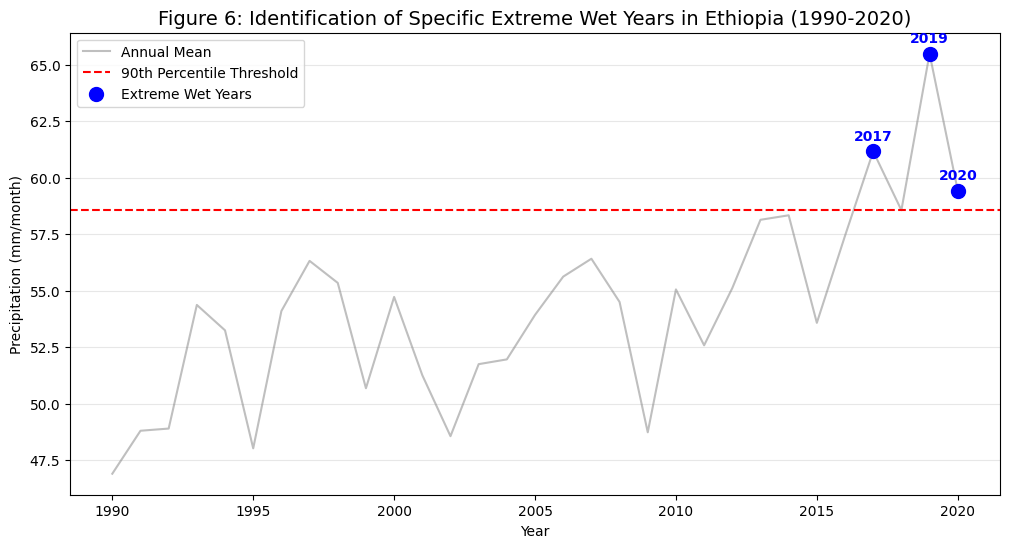

In [21]:
# 1. Calculate the spatial average of annual mean precipitation for the whole country
# This gives us one value per year for Ethiopia
ethiopia_annual_series = annual_grid.mean(dim=['lat', 'lon'])

# 2. Calculate the 90th percentile threshold for the country-wide series
threshold_90_country = ethiopia_annual_series.quantile(0.9)

# 3. Identify which specific years are 'Wet Years'
# We filter the series to only include years where the value > threshold
wet_years_data = ethiopia_annual_series.where(ethiopia_annual_series > threshold_90_country, drop=True)

# 4. Extract the years and their values
specific_wet_years = wet_years_data.time.dt.year.values
wet_values = wet_years_data.values

print(f"90th Percentile Threshold: {threshold_90_country.values:.2f} mm/month")
print("-" * 30)
print("Specific Wet Years identified for Ethiopia:")
for year, val in zip(specific_wet_years, wet_values):
    print(f"Year: {year} | Mean Precipitation: {val:.2f} mm/month")

# 5. Visualization: Highlight Wet Years on the Time Series
plt.figure(figsize=(12, 6))
plt.plot(ethiopia_annual_series.time.dt.year, ethiopia_annual_series, color='gray', alpha=0.5, label='Annual Mean')
plt.axhline(threshold_90_country, color='red', linestyle='--', label='90th Percentile Threshold')

# Scatter plot for the specific wet years
plt.scatter(specific_wet_years, wet_values, color='blue', s=100, label='Extreme Wet Years', zorder=5)

# Label the years on the plot
for year, val in zip(specific_wet_years, wet_values):
    plt.text(year, val + 0.5, str(year), fontweight='bold', ha='center', color='blue')

plt.title('Figure 6: Identification of Specific Extreme Wet Years in Ethiopia (1990-2020)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Precipitation (mm/month)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Identification of Specific Extreme Wet Years in Ethiopia.png', dpi=300, bbox_inches='tight')
plt.show()